XGBoost

Feature Importance  - Face mask before mandates - base model  

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier
import joblib

In [2]:
# downloadig data from the rf model code

# face mask before mandates train set
before_train_facemask = pd.read_csv("before_train_facemask.csv")

# remove the target variables and identifiers
drop_cols = ['RecordNo', 'Date','face_mask_scale', 'face_mask_binary','general_protective_behavior_scale',
              'general_protective_behavior_binary','mandate_start_date',
              '7days_rolling_cases','7days_rolling_deaths']


# train set
x_train = before_train_facemask.drop(columns=drop_cols)
x_train = x_train.astype(float)  # boolean to int

# target variable
y_train = before_train_facemask["face_mask_binary"]


# best rf model 
rf = joblib.load("facemask_before_baseModel_XGBoost_rolling.pkl")

# best rf hyper parameters
best_parameters = joblib.load("facemask_before_baseModel_XGBoost_bestParameters_rolling.pkl")

best_parameters

{'xgb__learning_rate': 0.05,
 'xgb__max_depth': 7,
 'xgb__min_child_weight': 7,
 'xgb__n_estimators': 250}

In [3]:
# to keep all the importances in each run
all_importances = []


for i in range(100):
    
    temp_xgb = Pipeline([
        ('ros', RandomOverSampler(random_state=i)),
        ('xgb', XGBClassifier(random_state=i,
                              eval_metric='logloss',
                              n_jobs=-1))
        ])

    temp_xgb.set_params(**best_parameters)

    temp_xgb.fit(x_train, y_train)

    all_importances.append(temp_xgb.named_steps['xgb'].feature_importances_)

median importance

Feature Importance                                      Feature  Importance
17                     state_New South Wales    0.142956
6           protective_behavior_nomask_scale    0.120576
21                            state_Tasmania    0.023874
4                         Perceived Severity    0.021040
7                                       week    0.020083
1                                        age    0.017571
5                   Perceived Susceptibility    0.017236
23                   state_Western Australia    0.016555
15        Isolate if instructed_Very willing    0.016496
24             employment_status_Not working    0.016435
58             comorbidities_consent_removed    0.016159
27              employment_status_Unemployed    0.015841
10                     Isolate if unwell_Yes    0.015049
57                         comorbidities_Yes    0.014666
49  Can't control worrying_Prefer not to say    0.014487


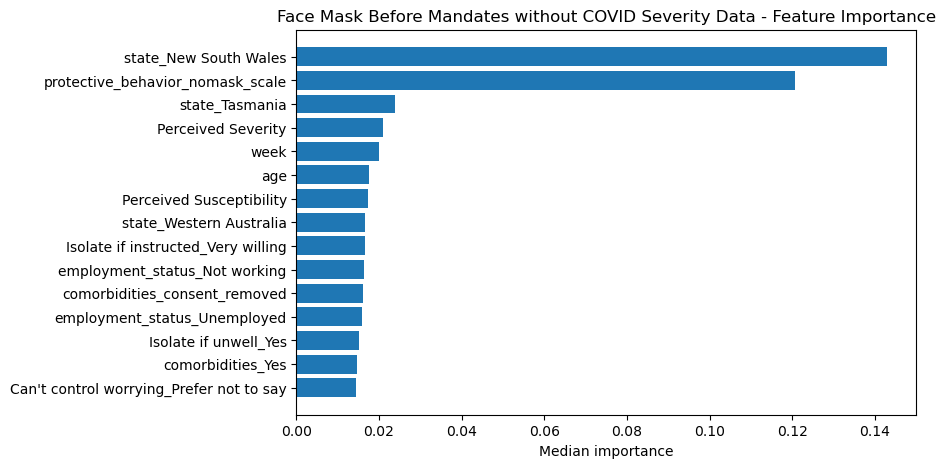

In [4]:
all_importances = np.array(all_importances)

# take the median / mean
median_importance = np.median(all_importances, axis=0) # take the median of each column(feature) 


feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": median_importance
})


feature_importance = feature_importance.sort_values("Importance",ascending=False)

top15 = feature_importance.head(15)

print(f"Feature Importance",top15)
feature_importance.to_csv("facemask_before_baseModel_XGBoost_FeatureImportance_rolling.csv",index=False)


# plot
plt.figure(figsize=(8,5))
plt.barh(top15["Feature"], top15["Importance"])
plt.title("Face Mask Before Mandates without COVID Severity Data - Feature Importance")
plt.xlabel("Median importance")
plt.gca().invert_yaxis()
plt.savefig("facemask_before_baseModel_XGBoost_FeatureImportance_rolling.png",dpi=300,bbox_inches="tight")
plt.show()


mean importance

Feature Importance                                      Feature  Importance
17                     state_New South Wales    0.142956
6           protective_behavior_nomask_scale    0.120576
21                            state_Tasmania    0.023874
4                         Perceived Severity    0.021040
7                                       week    0.020083
1                                        age    0.017571
5                   Perceived Susceptibility    0.017236
23                   state_Western Australia    0.016555
15        Isolate if instructed_Very willing    0.016496
24             employment_status_Not working    0.016435
58             comorbidities_consent_removed    0.016159
27              employment_status_Unemployed    0.015841
10                     Isolate if unwell_Yes    0.015049
57                         comorbidities_Yes    0.014666
49  Can't control worrying_Prefer not to say    0.014487


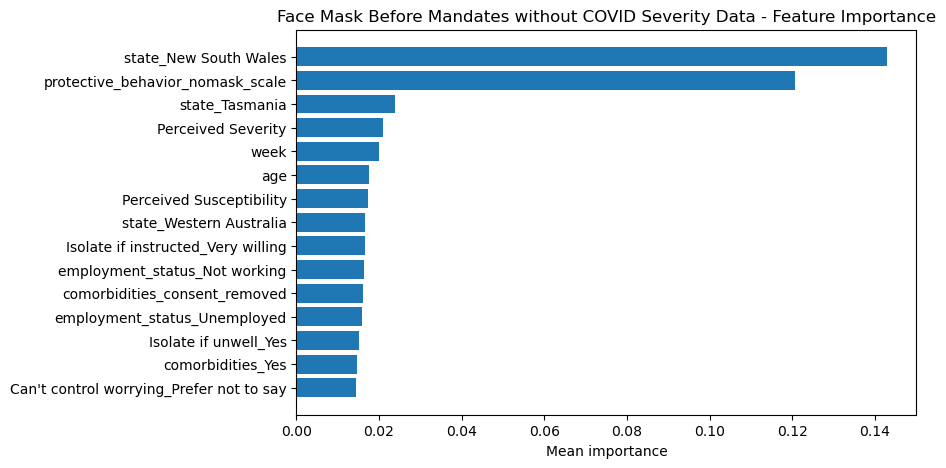

In [5]:
all_importances = np.array(all_importances)

# take the median / mean
mean_importance = np.mean(all_importances, axis=0) # take the median of each column(feature) 


feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": median_importance
})

feature_importance = feature_importance.sort_values("Importance",ascending=False)

top15 = feature_importance.head(15)

print(f"Feature Importance",top15)
# feature_importance.to_csv("facemask_before_baseModel_RF_FeatureImportance_rolling.csv",index=False)


# plot
plt.figure(figsize=(8,5))
plt.barh(top15["Feature"], top15["Importance"])
plt.title("Face Mask Before Mandates without COVID Severity Data - Feature Importance")
plt.xlabel("Mean importance")
plt.gca().invert_yaxis()
# plt.savefig("facemask_before_baseModel_RF_FeatureImportance_rolling.png",dpi=300,bbox_inches="tight")
plt.show()
